# Experiements. 
Code snipets for me to understand the code written by claude 

**Reading Order**
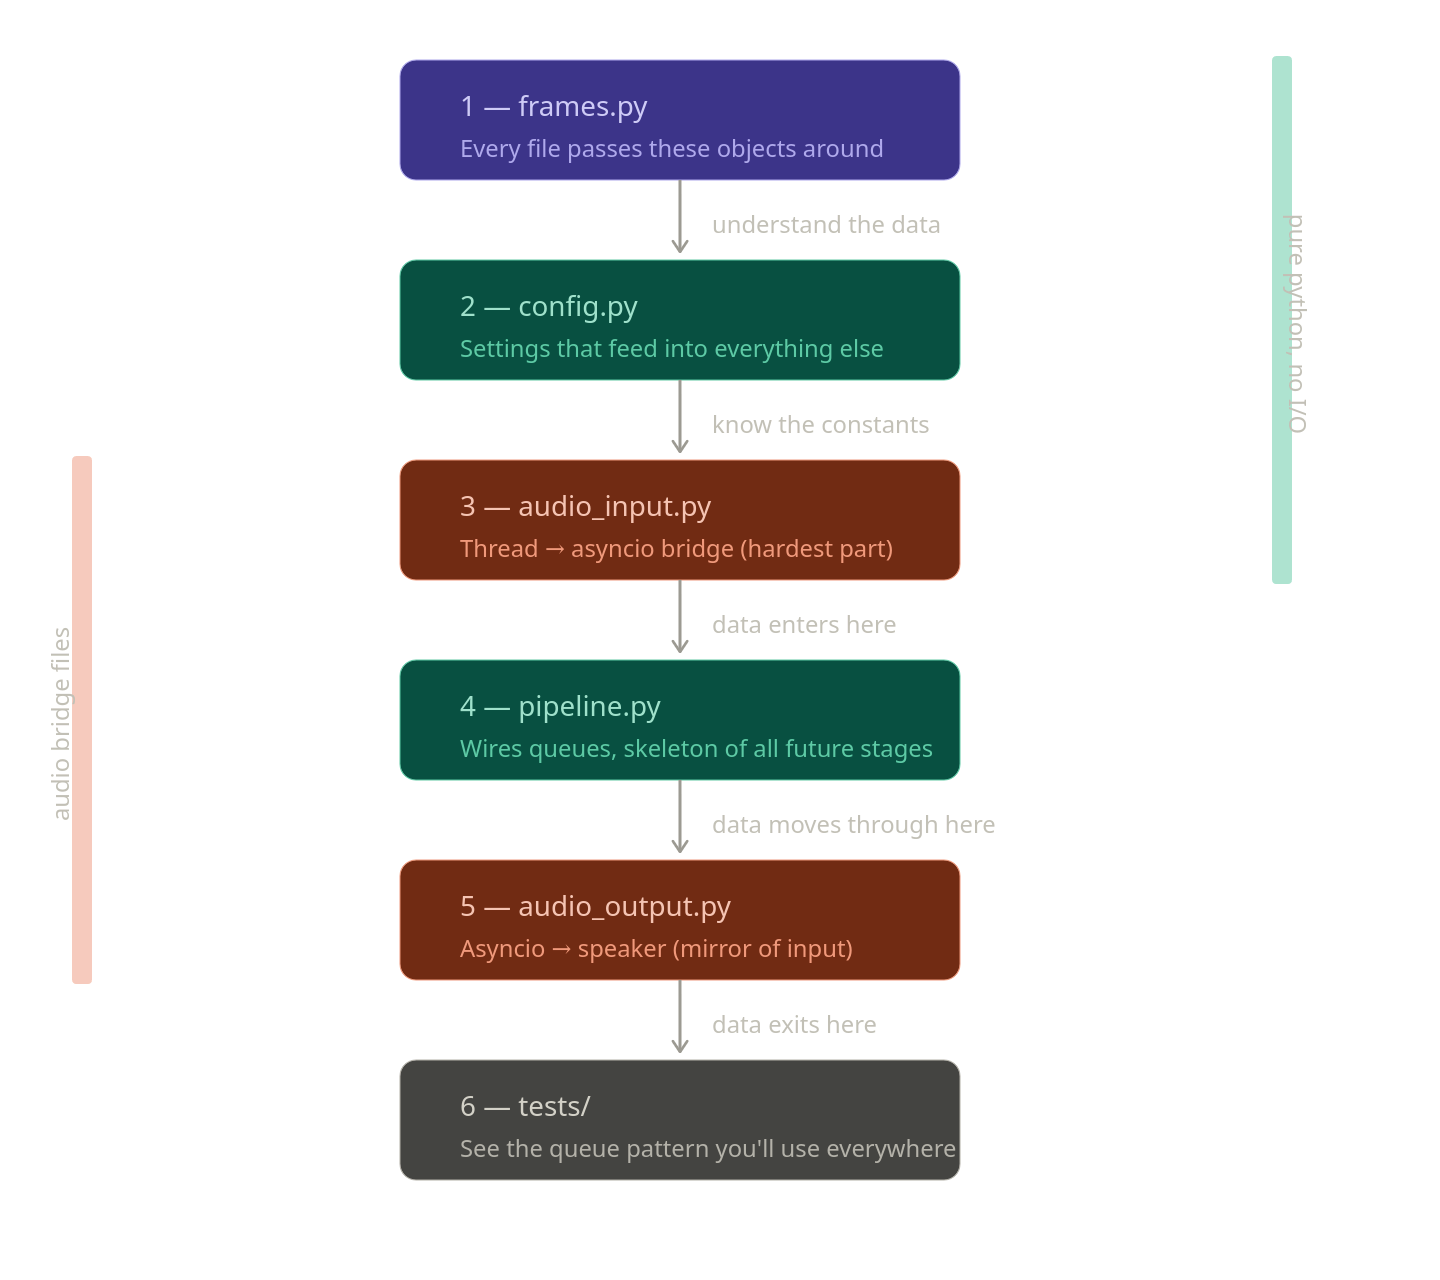

## Issues #1 and #2

# `frames.py` — the pipeline's shared vocabulary

Every message that flows through the voice agent pipeline is a **Frame**. Frames are the only thing queues carry — the pipeline never passes raw data directly, always a typed frame. This notebook walks through each frame type and lets you interact with them.
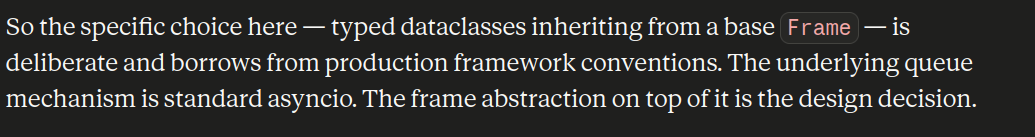

## The base class

```python
@dataclass
class Frame:
    pass
```

Intentionally empty. It exists as a **type anchor** so you can write `isinstance(x, Frame)` anywhere in the pipeline to confirm something belongs to the frame hierarchy. It also lets you type queues as `asyncio.Queue[Frame]` and have all subtypes accepted.

In [2]:
from dataclasses import dataclass

@dataclass
class Frame:
    pass

## Control frames — signals, not data

`StartFrame` and `EndFrame` carry no payload. Their **type is the message**.

- `StartFrame` — reserved for stages that need a setup phase before processing audio (not yet used).
- `EndFrame` — the **poison pill**. Every processor that receives it must forward it downstream and then stop. One `EndFrame` travels through every stage in sequence, causing each to exit its loop cleanly.

In [ ]:
import sys; sys.path.insert(0, "..")
from src.frames import Frame, StartFrame, EndFrame

start = StartFrame()
end = EndFrame()

print(isinstance(start, Frame))  # True — both are Frames
print(isinstance(end, Frame))    # True
print(type(start), type(end))

## `AudioRawFrame` — the data carrier

Carries a chunk of raw PCM audio. Three fields:

| Field | Type | Purpose |
|---|---|---|
| `audio` | `bytes` | Raw PCM samples (little-endian 16-bit by convention) |
| `sample_rate` | `int` | Samples per second — typically `16000` |
| `num_channels` | `int` | `1` for mono (required by VAD/STT models), `2` for stereo |

`sample_rate` and `num_channels` are carried **on the frame itself** so frames are self-describing — a downstream stage doesn't need to consult global config to know what it received.

### `__post_init__` — runtime type guards

`@dataclass` doesn't enforce field types at runtime. `__post_init__` runs immediately after `__init__` and raises `TypeError` early if the wrong type is passed (e.g. a `numpy` array instead of `bytes`), catching bugs at the point of construction rather than deep inside a processor.

In [ ]:
from src.frames import AudioRawFrame

# Valid frame
frame = AudioRawFrame(audio=b"\x00" * 64, sample_rate=16000, num_channels=1)
print(frame)
print(f"audio length: {len(frame.audio)} bytes")

# Type guard in action
try:
    bad = AudioRawFrame(audio="not bytes", sample_rate=16000, num_channels=1)
except TypeError as e:
    print(f"\nTypeError caught at construction: {e}")

## VAD event frames — speaking state transitions

Emitted by `VADProcessor` when it detects a change in speaking state. Like control frames, they carry no payload — their type is the message.

- `UserStartedSpeakingFrame` → emitted on the first speech frame after silence; downstream stages use this to start buffering audio for transcription.
- `UserStoppedSpeakingFrame` → emitted on the first silence frame after speech; downstream stages use this to flush their buffer and send it to the STT model.

The VAD processor always emits the transition frame **before** forwarding the `AudioRawFrame` that triggered it, so the downstream stage knows what to do with the audio chunk it's about to receive.

In [ ]:
import asyncio
from src.frames import AudioRawFrame, EndFrame, UserStartedSpeakingFrame, UserStoppedSpeakingFrame
from src.processors.vad.base import VADProvider
from src.processors.vad.processor import VADProcessor

class MockVADProvider:
    def __init__(self, responses):
        self._responses = iter(responses)
    def is_speech(self, audio, sample_rate):
        return next(self._responses)

async def demo():
    input_q, output_q = asyncio.Queue(), asyncio.Queue()
    # silence → speech → speech → silence → end
    for _ in range(4):
        input_q.put_nowait(AudioRawFrame(b"\x00" * 32, 16000, 1))
    input_q.put_nowait(EndFrame())

    await VADProcessor(MockVADProvider([False, True, True, False]), input_q, output_q).run()

    while not output_q.empty():
        f = output_q.get_nowait()
        print(type(f).__name__)

asyncio.run(demo())